In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import sys
import os
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_style("whitegrid")

### load Dataset

In [4]:
df= pd.read_csv('shoes_sales_dataset.csv')

Observations:- The dataset was loaded into dataframe

### Structure of Dataset 

In [5]:
df

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48
...,...,...,...,...,...,...,...,...,...,...
995,S996,2025-06-06,Puma,Sneakers,Red,India,Online,50.15,6,300.90
996,S997,2025-08-14,Adidas,Casual,Green,France,Online,231.81,2,463.62
997,S998,2025-02-13,Skechers,Running,White,India,Online,60.10,4,240.40
998,S999,2025-05-28,Puma,Boots,Black,France,Retail Store,239.05,1,239.05


In [ ]:
df.head()

Observations: head fuctions return automatically first 5 columns, Where dataset contains shoes related info like Sale_Id, Date	Brand, Shoe_Type	Color, Country,	Sales_Channel,	Price,	Units_Sold and	Revenue

In [13]:
df.sample(5)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
47,S48,2025-10-05,Skechers,Sports,Black,USA,Mall,144.41,2,288.82
256,S257,2025-06-28,Skechers,Boots,White,UK,Online,235.95,12,2831.40
606,S607,2025-09-27,Skechers,Sneakers,Black,Germany,Mall,75.39,8,603.12
430,S431,2025-12-11,New Balance,Running,Black,UK,Mall,61.46,20,1229.20
718,S719,2025-12-09,Adidas,Running,Grey,USA,Mall,57.35,16,917.60


Observations-> Sample used to randomly inspect sales records and verify the dataset structure, data quality, and consistency of values before performing analysis.

In [15]:
df.shape


(1000, 10)

Observations-> shape shows how many rows and columns present in the whole data

In [19]:
df.columns

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

Observations-> Columns was used to see all the column names in the dataset and make sure all required columns are present for further analysis.

### Check datatypes of all columns

In [29]:
df.dtypes

Sale_ID                  object
Date             datetime64[ns]
Brand                    object
Shoe_Type                object
Color                    object
Country                  object
Sales_Channel            object
Price_USD               float64
Units_Sold                int64
Revenue_USD             float64
dtype: object

Observations-> dtypes used to see the type of data in each column, such as text, numbers, or dates, and to make sure the data is in the correct format for analysis.

### Convert Data types

In [26]:
df['Date']= pd.to_datetime(df['Date'])

# Enables month-wise, quarter-wise and yearly analysis.

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sale_ID        1000 non-null   object        
 1   Date           1000 non-null   datetime64[ns]
 2   Brand          1000 non-null   object        
 3   Shoe_Type      1000 non-null   object        
 4   Color          1000 non-null   object        
 5   Country        1000 non-null   object        
 6   Sales_Channel  1000 non-null   object        
 7   Price_USD      1000 non-null   float64       
 8   Units_Sold     1000 non-null   int64         
 9   Revenue_USD    1000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 78.3+ KB


Observations:-  
-> The dataset has 1000 records and 10 columns.

-> All columns have 1000 values, which means there are no missing values.

-> The dataset contains text, numbers, and date values.

-> The Date column is in the correct date format.

-> The Price_USD and Revenue_USD columns contain decimal numbers.

-> The Units_Sold column contains whole numbers.

-> The data is properly formatted and ready for analysis

### Finding the missing value in the dataset

In [30]:
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

Observartion-> All columns have 0 missing values, which means the dataset is complete and no data cleaning is needed for missing data.

### Check Duplicate Records

In [32]:
df.duplicated().sum()

np.int64(0)

Observations-> The dataset contains 0 duplicate records, which means all sales transactions are unique and no duplicate rows need to be removed.

### Generate Statistic Summary

In [33]:
df.describe()

,Date,Price_USD,Units_Sold,Revenue_USD
count,1000,1000.000000,1000.000000,1000.00000
mean,2025-07-01 12:28:48,137.856420,10.584000,1453.18603
min,2025-01-03 00:00:00,31.020000,1.000000,32.38000
25%,2025-04-03 18:00:00,81.915000,6.000000,561.05000
50%,2025-06-28 12:00:00,139.295000,10.000000,1132.62500
75%,2025-10-03 00:00:00,193.752500,16.000000,2163.35000
max,2025-12-31 00:00:00,249.940000,20.000000,4938.40000
std,NaN,64.270059,5.842181,1112.32648


Observations->

-> The dataset contains 1000 shoe sales records.

-> The average price of a shoe is 137.86 USD.

-> The lowest shoe price is 31.02 USD and the highest price is 249.94 USD.

-> On average, 11 shoes are sold in each transaction.

-> The number of shoes sold in a transaction ranges from 1 to 20 units.

-> The average revenue per sale is 1453.19 USD.

-> The lowest revenue from a sale is 32.38 USD, while the highest revenue is 4938.40 USD.

-> Most shoe prices are between 81.92 USD and 193.75 USD.

-> Most transactions sold between 6 and 16 units.

-> Most sales generated revenue between 561.05 USD and 2163.35 USD.

### Univariate Analysis

#### Histogram- Price Distribution

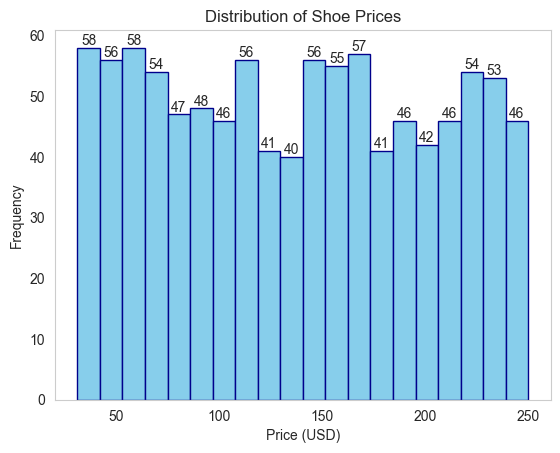

In [55]:
n, bins, patches= plt.hist(df['Price_USD'], bins=20,
        edgecolor= 'darkblue',
    color= 'Skyblue',
)
plt.title('Distribution of Shoe Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.grid(False)

# Adding count above each bar
for i in range(len(n)):
    plt.text(
        bins[i] + (bins[1] - bins[0]) / 2, n[i],  # center of bar  and n[i] height of bar
        str(int(n[i])),
# count
        ha= 'center',
        va= 'bottom',
        fontsize= 10
        
        
)
            
plt.show()


Observations:

 -> Shoe prices are distributed across different price ranges.
 
 -> Most price ranges have a similar number of shoes.
 
 -> There is no strong peak, so the prices are fairly evenly distributed.
 
 -> No major outliers visible in the histogram.    

#### Histogram- Revenue Distribution

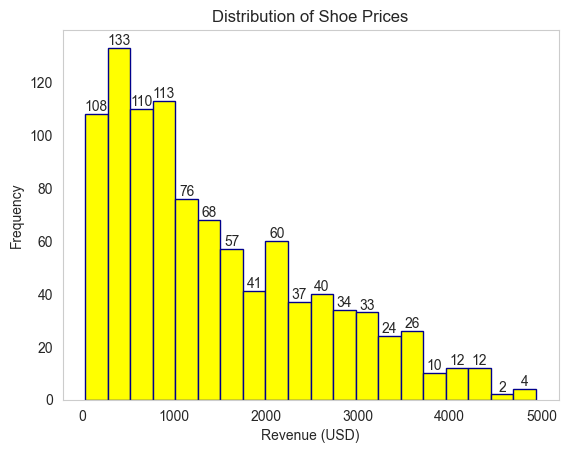

In [63]:
n, bins, patches= plt.hist(df['Revenue_USD'], bins=20,
        edgecolor= 'darkblue',
    color= 'Yellow',
)
plt.title('Distribution of Shoe Prices')
plt.xlabel('Revenue (USD)')
plt.ylabel('Frequency')
plt.grid(False)

# Adding count above each bar
for i in range(len(n)):
    plt.text(
        bins[i] + (bins[1] - bins[0]) / 2, n[i],  # center of bar  and n[i] height of bar
        str(int(n[i])),
# count
        ha= 'center',
        va= 'bottom',
        fontsize= 10
        
        
)
            
plt.show()


Observation: 

->Most sales generated medium revenue, while very low and very high revenue sales were fewer in number.

### Bar Graph- Brand Count

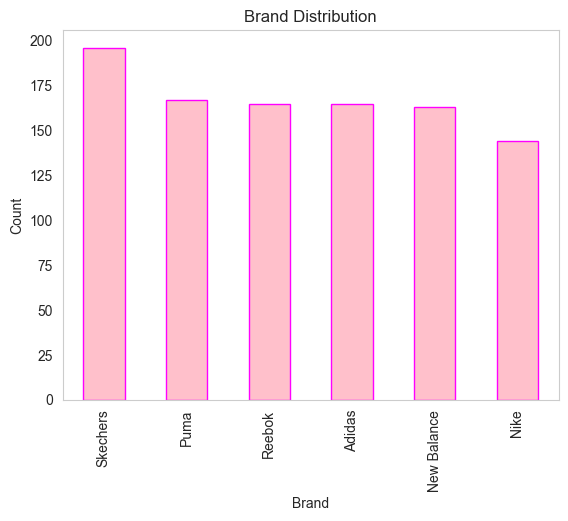

In [69]:
df['Brand'].value_counts().plot(kind= 'bar',
                               color= 'pink',
                               edgecolor= 'Magenta'
                              )
plt.title('Brand Distribution')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.grid(False)
plt.show()

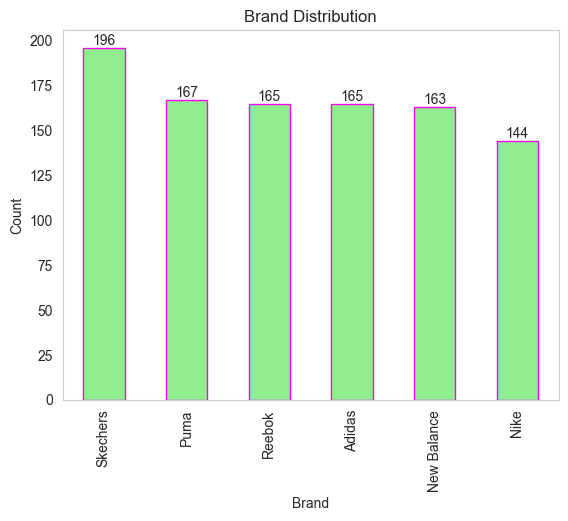

In [74]:
x = df['Brand'].value_counts().plot(
    kind='bar',
    color='LightGreen',
    edgecolor='magenta'
)

# Show count above each bar using enumerate
for i, v in enumerate(df['Brand'].value_counts()):
    plt.text(
        i,          # x position
        v,          # y position
        str(v),     # text to display
        ha='center',
        va='bottom'
    )

plt.title('Brand Distribution')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.grid(False)

plt.show()

Observations:


-> A bar chart was created to show the number of sales for each shoe brand.

-> value_counts() was used to count the number of sales for each brand.

-> enumerate() was used to get the position and count of each bar so that the count value could be displayed above the bars.

-> The chart helps identify the most sold and least sold brands in the dataset.

### Bar Graph - Shoe_Type Bar

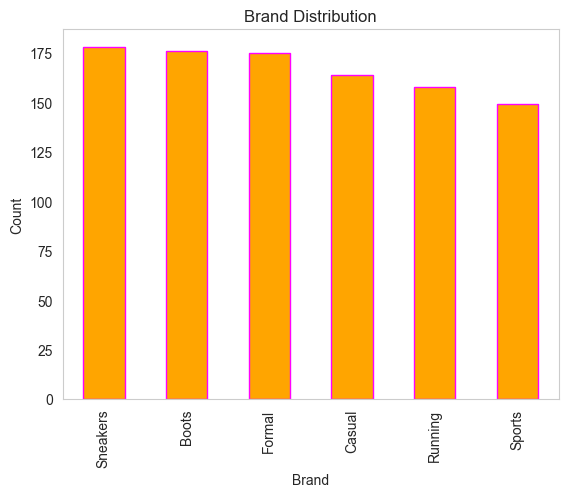

In [77]:
df['Shoe_Type'].value_counts().plot(kind= 'bar',
                               color= 'Orange',
                               edgecolor= 'Magenta'
                              )
plt.title('Shoe Type Distribution')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.grid(False)
plt.show()

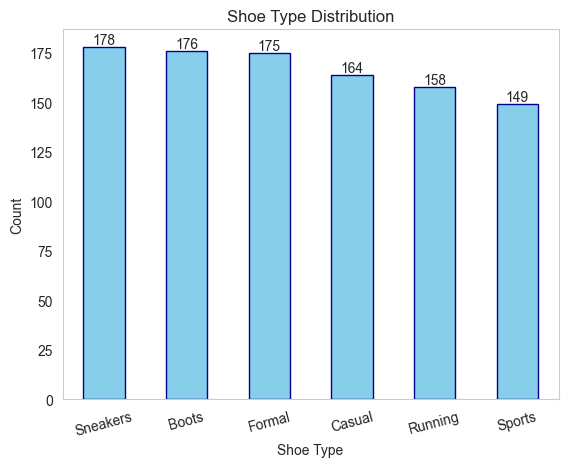

In [16]:
y = df['Shoe_Type'].value_counts().plot(
    kind='bar',
    color='skyblue',
    edgecolor='darkblue'
)

# Show count above each bar
for i, v in enumerate(df['Shoe_Type'].value_counts()):
    plt.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Shoe Type Distribution')
plt.xlabel('Shoe Type')
plt.ylabel('Count')
plt.xticks(rotation=15)  # then the x-axis labels will be tilted 15 degrees to the right.
plt.grid(False)

plt.show()

Observations:

-> The bar chart shows the number of sales for each shoe type in the dataset.
    
-> Shoe types with taller bars were sold more frequently, while shorter bars had fewer sales.
    
-> The count values displayed above each bar make it easy to compare the popularity of different shoe types.

### Bar Graph- Sales Channel Distribution

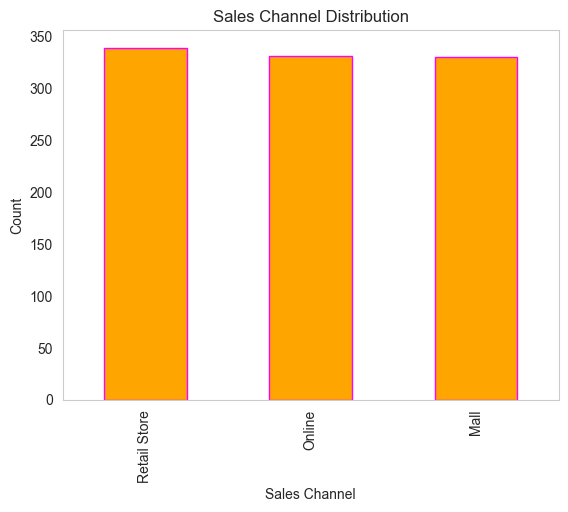

In [19]:
df['Sales_Channel'].value_counts().plot(kind= 'bar',
                               color= 'Orange',
                               edgecolor= 'Magenta'
                              )
plt.title('Sales Channel Distribution')
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.grid(False)
 
plt.show()

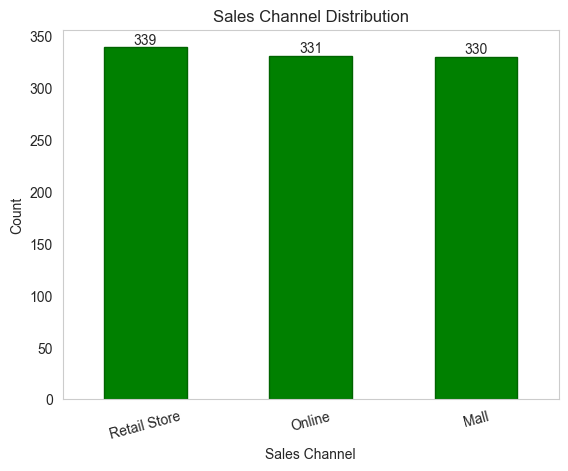

In [18]:
z  = df['Sales_Channel'].value_counts().plot(
    kind='bar',
    color='Green',
    edgecolor='DarkGreen'
)

# Show count above each bar
for i, v in enumerate(df['Sales_Channel'].value_counts()):
    plt.text(
        i,
        v,
        str(v),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Sales Channel Distribution')
plt.xlabel('Sales Channel')
plt.ylabel('Count')
plt.xticks(rotation=15)  # then the x-axis labels will be tilted 15 degrees to the right.
plt.grid(False)

plt.show()

Observation:

-> The bar chart shows the distribution of shoe sales across different sales channels such as Online, Mall, and Retail Store.
    
-> Sales channels with taller bars recorded more transactions, indicating higher customer preference.
    
-> The count values above the bars make it easy to compare the number of sales in each channel.

### Outliers Detection

### Boxplot - Price Outliers

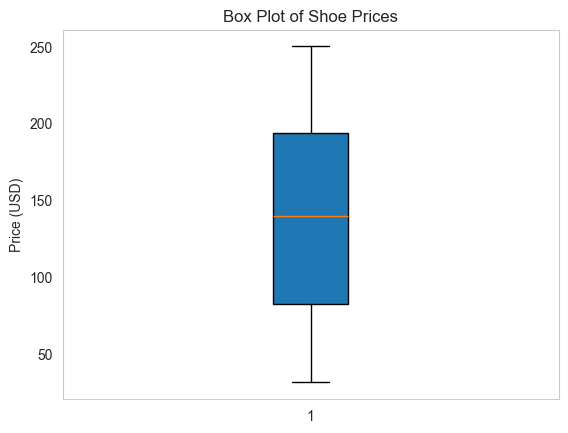

In [25]:
plt.boxplot(df['Price_USD'], patch_artist=True)
plt.title('Box Plot of Shoe Prices')
plt.ylabel('Price (USD)')
plt.grid(False)

plt.show()

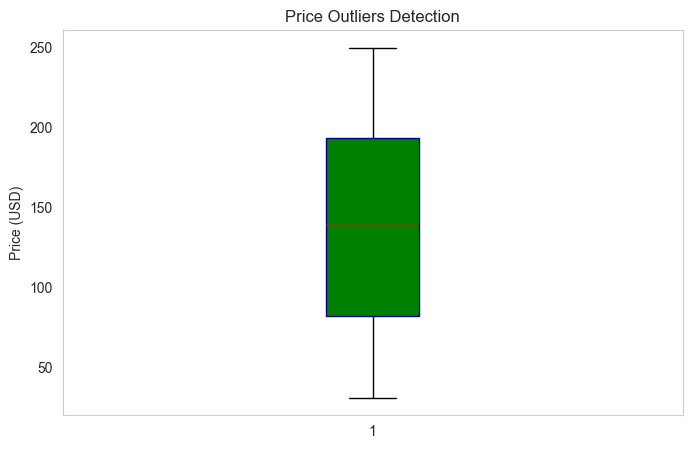

In [33]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df['Price_USD'],
    patch_artist=True,                    # Fills color inside the box. Without this, the box remains unfilled (white).
    boxprops=dict(facecolor='Green',      # fills the box with green color.
                  color='darkblue'),      # sets the border color of the box to dark blue.
    medianprops=dict(color='red')         # The median line appears in red.
)

plt.title('Price Outliers Detection')
plt.ylabel('Price (USD)')
plt.grid(False)                          # This will remove backside square box

plt.show()

Observations:

-> The box plot was used to analyze the distribution of shoe prices and detect any outliers in the Price_USD column.
    
-> The median shoe price is around 139 USD, and most shoe prices are concentrated within a similar range.
    
->There are no significant outliers visible, which suggests that the shoe prices are fairly consistent across the dataset.

### Boxplot - Revenue Outliers

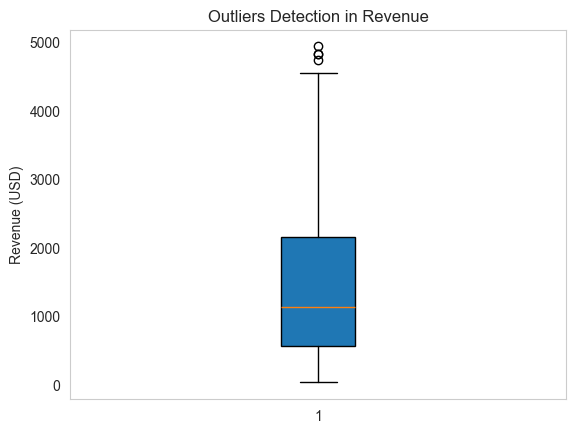

In [39]:
plt.boxplot(df['Revenue_USD'], patch_artist=True)
plt.title('Outliers Detection in Revenue')
plt.ylabel('Revenue (USD)')
plt.grid(False)

plt.show()

Observations:

-> Some transactions generated unusually high revenue.

-> These may represent bulk purchase or high price product.    

### Bivariate Analysis

#### Scatter plot - Price Vs Revenue 

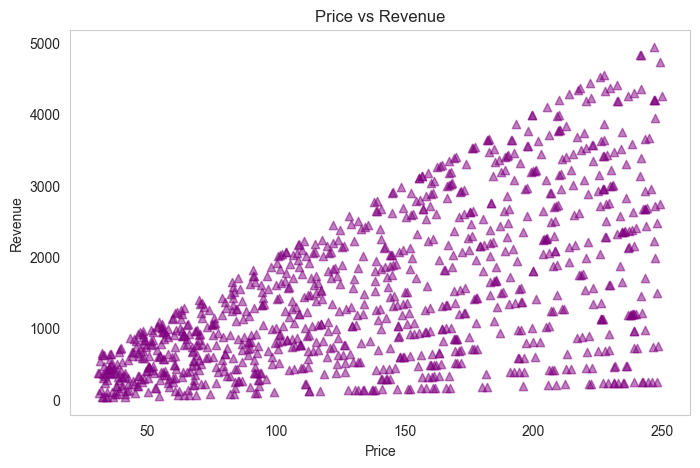

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['Price_USD'], df['Revenue_USD'], color= 'Purple', marker= "^", alpha= 0.5 )

plt.title('Price vs Revenue')
plt.xlabel('Price')
plt.ylabel('Revenue')
plt.grid(False)
plt.show()

Observations:

Revenue and price are proportional to each other, means revenue increase as price increase.
* Revenue = price * units sold

High prices shows often generated high value.


  

#### Scatter plot - Units sold VS Revenue

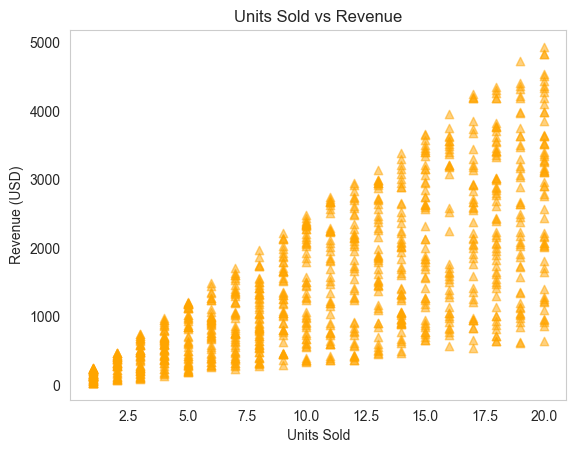

In [27]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(8,5))

plt.scatter(
    df['Units_Sold'],  # column name
    df['Revenue_USD'], # column name
    color='orange',
    marker='^',
    alpha=0.5
)

plt.title('Units Sold vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue (USD)')
plt.grid(False)

plt.show()

Observations:

-> Revenue will increase more when the unit sold more.

-> Strong positive relation between revenue and unit price.


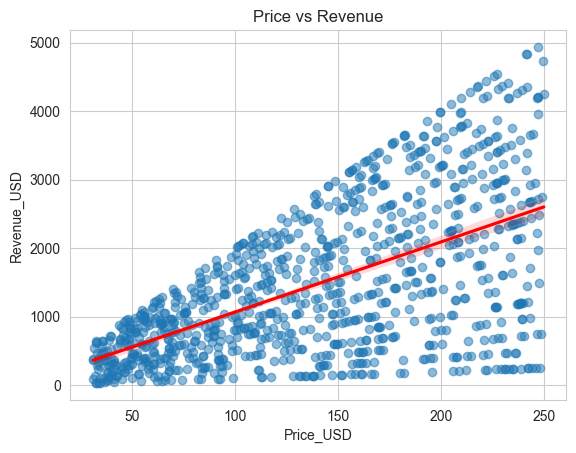

In [18]:

sns.regplot(
    x='Price_USD',
    y='Revenue_USD',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title('Price vs Revenue')
plt.show()

#### Group by Analysis

#### Brand-wise Revenue

In [31]:
df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)

Brand
Skechers       269168.63
New Balance    261631.68
Adidas         257039.04
Reebok         238826.94
Puma           233749.59
Nike           192770.15
Name: Revenue_USD, dtype: float64

Observations:

-> The brand at the top generated the highest revenue and performed the best in sales.

-> The brand at the bottom generated the lowest revenue and had lower sales compared to other brands.

### Brand vs Unit_sold

In [43]:
df.groupby('Brand')['Price_USD'].mean()

Brand
Adidas         137.185636
New Balance    144.850798
Nike           131.868472
Puma           137.835449
Reebok         138.991636
Skechers       136.065867
Name: Price_USD, dtype: float64

### Shoe Type-wise Units Sold

In [40]:
df.groupby('Shoe_Type')['Units_Sold'].sum().sort_values(ascending=False)

Shoe_Type
Sneakers    1979
Formal      1872
Boots       1866
Casual      1715
Running     1659
Sports      1493
Name: Units_Sold, dtype: int64

Observations:

-> Customers bought more Sneakers than any other shoe type.
    
-> Customers bought fewer Sports shoes compared to other shoe types.

### Correlation Analysis

In [44]:
corr = df[['Price_USD', 'Units_Sold', 'Revenue_USD']].corr()

print(corr)

             Price_USD  Units_Sold  Revenue_USD
Price_USD     1.000000   -0.015693     0.591029
Units_Sold   -0.015693    1.000000     0.725185
Revenue_USD   0.591029    0.725185     1.000000


### Correlation Heatmap Using Matplotlib

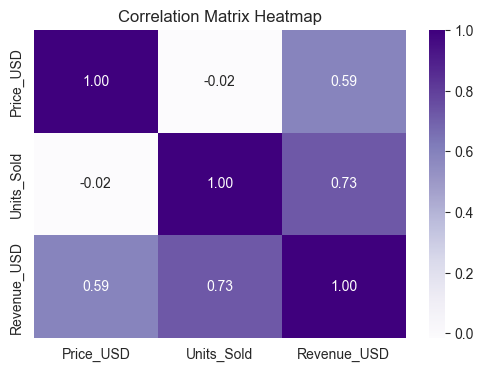

In [49]:

# Create correlation matrix
corr = df[['Price_USD', 'Units_Sold', 'Revenue_USD']].corr()

# Create heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,      # Show correlation values inside the boxes
    cmap='Purples', # Color theme
    fmt='.2f'        # Display values with 2 decimal places
)

plt.title('Correlation Matrix Heatmap')
plt.show()

Observations:

-> Units Sold and Revenue are strongly related.
    
-> Price and Revenue are positively related.
    
-> Price and Units Sold have a weak relationship.

#### Business Questions Solved:-

Q.1 Which factors affects revenue more price or units sold?

-> Units sold has a stronger relationship with revenue compared to price.

Q.2 Which sales channel contributions most?

-> Retail store channel contributed the highest numbers of sales record.

Q.3 Do premium priced shoes generated more revenue?

-> Yes, higher priced shoes generally generated higher revenue.

Q.4 Are there any unsual transactions?

-> Yes, some transactions generated extremely high revenue and were identified as outliers.

Q.5 Do all brands perform equally?

-> No, some brands contributed higher average revenue compared to others.
    

### Key business insights

1. Sneakers were the most sold shoe type.
2. The top brand earned the highest revenue.
3. More shoes sold means more revenue.
4. Some countries and sales channels performed better than others.
5. These insights can help the company increase sales and make better business decisions.

### Business Impact

Problem 1. Company did not know which factor increases revenue most

Solution:-

-> EDA showed that Units_Sold has the strongest relationship with revenue.

Business Benefit:

-> The company should focus on increasing product demand and sales volume to improve revenue.

Problem 2: The company did not know which sales channel performs best.

Solution:-

-> The Retail Store channel showed higher sales activity compared to other channels.

Business Benefit:

-> The company can invest more in high-performing channels for better returns.

Problem 3: The company did not know whether premium products are profitable.

Solution:-

-> Higher-priced shoes generally generated higher revenue.

Business Benefit:

-> The company can focus more on premium product strategy to increase profits.

Problem 4: The company did not know which brands perform better.

Solution:-

->Some brands generated higher average revenue than others.

Business Benefit:

-> High-performing brands can receive more marketing and inventory support.

Problem 5: The company did not know whether unusual transactions exist.

Solution:-

-> Outliers were identified in the revenue data.

Business Benefit:

-> The company can investigate large transactions, bulk orders, or special customer behavior.



#### Business Recommendation
Recommendation 1:
-> Business should focus more on high-performing brands because they generate better average revenue.

Recommendation 2:
-> The Retail Store channel performs strongly and should continue receiving marketing attention.

Recommendation 3:
-> Premium-priced shoes contribute higher revenue, so a premium product strategy can improve profits.

Recommendation 4:
-> Countries with higher sales demand should receive more inventory and promotional support.

Recommendation 5:
-> Outlier transactions should be monitored because they may represent bulk orders or special customers.


### Final Conclusion:

1. The dataset was successfully cleaned and analyzed.

2. No missing values or duplicate records remained after data cleaning.

3. Units_Sold had the strongest positive relationship with revenue.

4. The Retail Store channel performed better than other sales channels.

5. Premium-priced shoes generated higher revenue than lower-priced products.

6. Outliers were identified and can help detect bulk orders or unusual customer behavior.

7. This analysis helped us understand the shoe sales data better.
   
8. Sneakers were the most popular shoe type and had the highest sales.

9. Some brands earned more revenue than others.

10. Some countries and sales channels performed better than others.

11. When more shoes were sold, the revenue also increased.

12. The price of the shoes also affected the total revenue.

13. The charts and graphs made it easy to find sales trends and customer preferences.

14. These insights can help the company make better decisions about sales, marketing, and stock planning.

15. Overall, this analysis gives a clear picture of the business performance and customer buying patterns.

16. The analysis provides useful insights to improve sales, marketing, inventory management, and overall business decisions.


### Final Conclusion

1. The dataset was successfully cleaned and analyzed.
2. No missing values or duplicate records remained after data cleaning.
3. Units Sold had the strongest positive relationship with revenue.
4. The Retail Store channel performed better than the other sales channels.
5. Premium-priced shoes generated higher revenue than lower-priced shoes.
6. Outliers were identified, which may represent bulk orders or unusual sales.
7. Sneakers were the most popular shoe type and had the highest sales.
8. These insights can help the company improve sales, marketing, inventory management, and business decisions.

